# Notebook 12 — Transfer Functions & Control Systems

H(s) = Y(s)/X(s) = (bm*s^m + ... + b0) / (s^n + ... + a0)

Covered: TF from ODE, partial fractions, Bode plots, root locus, PID design, Routh-Hurwitz stability.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import math, warnings
warnings.filterwarnings('ignore')

class TransferFunction:
    'Rational TF H(s)=num(s)/den(s). Coefficients in descending power order.'

    def __init__(self, num, den):
        self.num = np.array(num, dtype=float)
        self.den = np.array(den, dtype=float)
        self._sys = signal.TransferFunction(num, den)

    def evaluate(self, s):
        return np.polyval(self.num, s) / np.polyval(self.den, s)

    @property
    def poles(self): return np.roots(self.den)
    @property
    def zeros(self): return np.roots(self.num)

    def is_stable(self):
        return bool(np.all(np.real(self.poles) < 0))

    def bode(self, omega=None):
        if omega is None:
            omega = np.logspace(-2, 3, 500)
        w, H = signal.freqs(self.num, self.den, worN=omega)
        return w, 20*np.log10(np.abs(H)+1e-300), np.angle(H, deg=True)

    def step_response(self, t=None):
        return signal.step(self._sys, T=t)

    def impulse_response(self, t=None):
        return signal.impulse(self._sys, T=t)

    def partial_fractions(self):
        return signal.residue(self.num, self.den)

# Example systems
H1 = TransferFunction([1], [2, 1])             # 1/(2s+1)  tau=2
wn, zeta = 4.0, 0.3
H2 = TransferFunction([wn**2], [1, 2*zeta*wn, wn**2])  # 2nd-order
H3 = TransferFunction([10, 10], [1, 2, 10])    # with zero

for name, H in [('H1 1st-order', H1), ('H2 2nd-order', H2), ('H3 with zero', H3)]:
    print(f'{name}: poles={np.round(H.poles,3)},  stable={H.is_stable()}')


H1 1st-order: poles=[-0.5],  stable=True
H2 2nd-order: poles=[-1.2+3.816j -1.2-3.816j],  stable=True
H3 with zero: poles=[-1.+3.j -1.-3.j],  stable=True


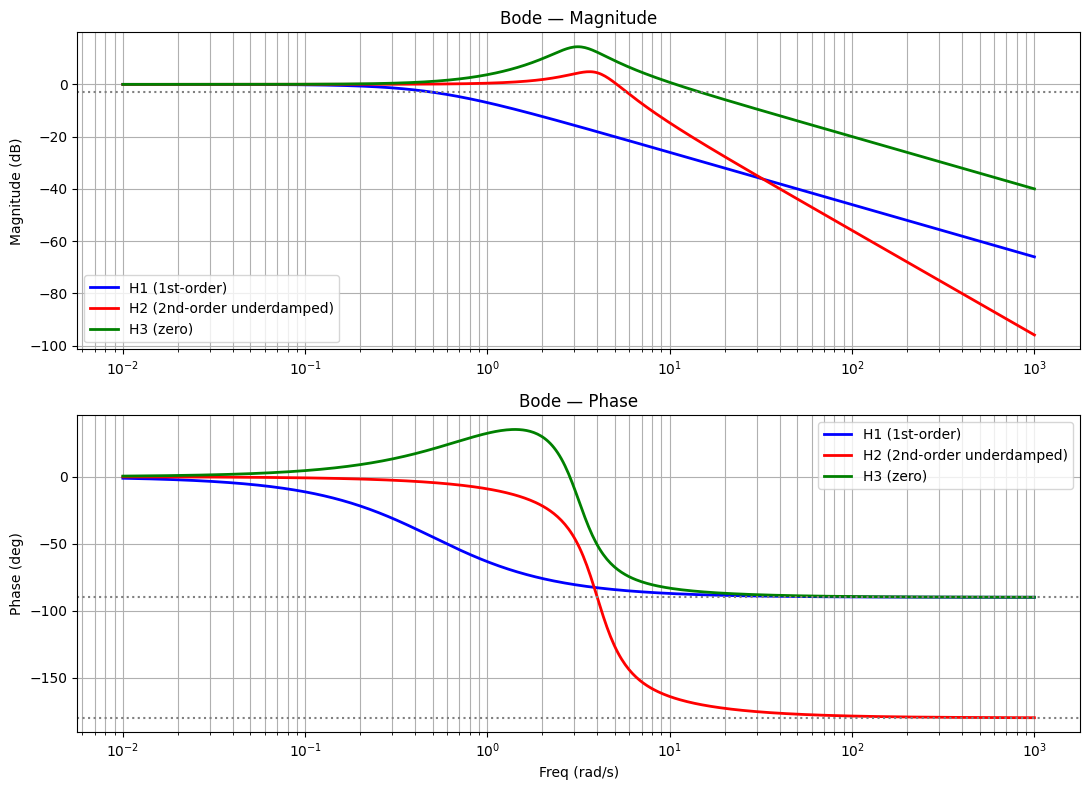

In [2]:
# Bode Plots
systems = [('H1 (1st-order)', H1), ('H2 (2nd-order underdamped)', H2), ('H3 (zero)', H3)]
colors  = ['blue', 'red', 'green']

fig, axes = plt.subplots(2, 1, figsize=(11, 8))
for (name, H), col in zip(systems, colors):
    w, mag, phase = H.bode()
    axes[0].semilogx(w, mag,   color=col, lw=2, label=name)
    axes[1].semilogx(w, phase, color=col, lw=2, label=name)

axes[0].axhline(-3, color='gray', ls=':')
axes[0].set_ylabel('Magnitude (dB)'); axes[0].set_title('Bode — Magnitude')
axes[0].legend(); axes[0].grid(True, which='both')

axes[1].axhline(-90, color='gray', ls=':'); axes[1].axhline(-180, color='gray', ls=':')
axes[1].set_xlabel('Freq (rad/s)'); axes[1].set_ylabel('Phase (deg)')
axes[1].set_title('Bode — Phase')
axes[1].legend(); axes[1].grid(True, which='both')
plt.tight_layout(); plt.show()


In [3]:
# Partial Fraction Expansion
# H(s) = sum r_k/(s-p_k) + direct terms  =>  h(t) = sum r_k * exp(p_k*t)
print('Partial Fraction Expansion')
print('='*50)
for name, H in [('H1', H1), ('H2', H2), ('H3', H3)]:
    r, p, k = H.partial_fractions()
    print(f'\n{name}:')
    for i, (ri, pi) in enumerate(zip(r, p)):
        sign = '+' if i > 0 else ' '
        print(f'  {sign} ({ri:.4f}) / (s - ({pi:.4f}))')
    if len(k): print(f'  Direct: {k}')


Partial Fraction Expansion

H1:
    (0.5000) / (s - (-0.5000))

H2:
    (0.0000-2.0966j) / (s - (-1.2000+3.8158j))
  + (0.0000+2.0966j) / (s - (-1.2000-3.8158j))

H3:
    (5.0000-0.0000j) / (s - (-1.0000+3.0000j))
  + (5.0000+0.0000j) / (s - (-1.0000-3.0000j))


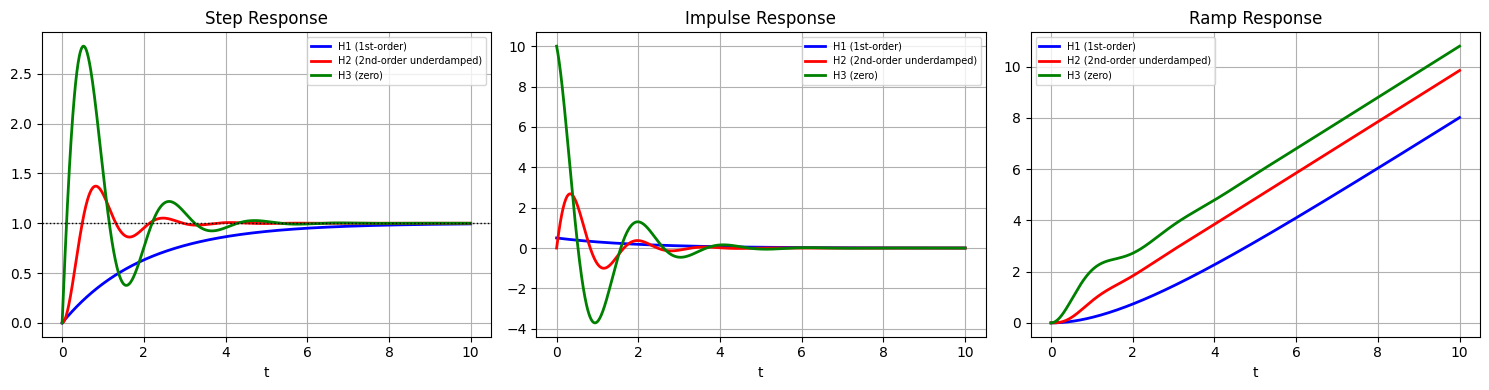

In [4]:
# Step, Impulse, and Ramp Responses
t_sim = np.linspace(0, 10, 1000)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for (name, H), col in zip(systems, colors):
    t_s, y_s = H.step_response(t=t_sim)
    t_i, y_i = H.impulse_response(t=t_sim)
    axes[0].plot(t_s, y_s, color=col, lw=2, label=name)
    axes[1].plot(t_i, y_i, color=col, lw=2, label=name)

# Ramp response via lsim
ramp_input = t_sim
for (name, H), col in zip(systems, colors):
    _, y_r, _ = signal.lsim(H._sys, ramp_input, t_sim)
    axes[2].plot(t_sim, y_r, color=col, lw=2, label=name)

axes[0].axhline(1.0, color='k', ls=':', lw=1)
titles = ['Step Response', 'Impulse Response', 'Ramp Response']
for ax, title in zip(axes, titles):
    ax.set_title(title); ax.set_xlabel('t'); ax.legend(fontsize=7); ax.grid(True)
plt.tight_layout(); plt.show()


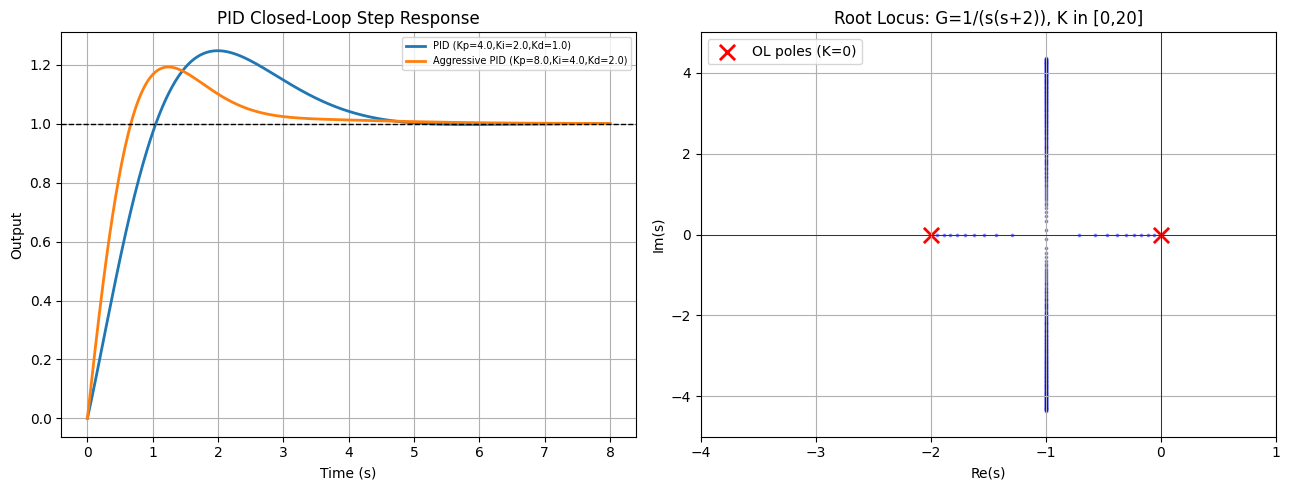

In [5]:
# PID Controller Design
# Plant: G(s) = 1/(s*(s+2))
# PID:   C(s) = Kp + Ki/s + Kd*s = (Kd*s^2 + Kp*s + Ki)/s
# CLTF = C*G / (1 + C*G)

def make_pid_cltf(Kp, Ki, Kd):
    # C*G = (Kd*s^2+Kp*s+Ki) / (s*(s+2)*s) ... 
    # G = 1/(s^2+2s), C = (Kd*s^2+Kp*s+Ki)/s
    # CG_num = Kd*s^2+Kp*s+Ki,  CG_den = s*(s^2+2s) = s^3+2s^2
    c_num = [Kd, Kp, Ki]
    cg_den = [1, 2, 0, 0]   # s^3 + 2s^2
    loop_num = c_num
    loop_den = cg_den
    # CLTF den = loop_den + [0,0,Kd,Kp,Ki] padded
    pad = len(loop_den) - len(loop_num)
    padded_num = [0]*pad + list(loop_num)
    cl_den = [a+b for a, b in zip(loop_den, padded_num)]
    try:
        return TransferFunction(loop_num, cl_den)
    except Exception:
        return None

pid_configs = [
    ('P only',        1.0, 0.0, 0.0),
    ('PD',            2.0, 0.0, 0.5),
    ('PID',           4.0, 2.0, 1.0),
    ('Aggressive PID',8.0, 4.0, 2.0),
]

t_eval = np.linspace(0, 8, 500)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, Kp, Ki, Kd in pid_configs:
    T = make_pid_cltf(Kp, Ki, Kd)
    if T and T.is_stable():
        t_s, y_s = T.step_response(t=t_eval)
        axes[0].plot(t_s, y_s, lw=2, label=f'{name} (Kp={Kp},Ki={Ki},Kd={Kd})')

axes[0].axhline(1.0, color='k', ls='--', lw=1)
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Output')
axes[0].set_title('PID Closed-Loop Step Response')
axes[0].legend(fontsize=7); axes[0].grid(True)

# Root locus for G=1/(s(s+2)), proportional control
# CL char. poly: s^2+2s+K
K_range = np.linspace(0.01, 20, 200)
for K in K_range:
    cl_den_rl = [1, 2, K]
    p = np.roots(cl_den_rl)
    axes[1].scatter(p.real, p.imag, s=3, c='blue', alpha=0.4)

axes[1].scatter([0, -2], [0, 0], s=120, marker='x', c='red', lw=2, label='OL poles (K=0)')
axes[1].axvline(0, color='k', lw=0.5); axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlim(-4, 1); axes[1].set_ylim(-5, 5)
axes[1].set_title('Root Locus: G=1/(s(s+2)), K in [0,20]')
axes[1].set_xlabel('Re(s)'); axes[1].set_ylabel('Im(s)')
axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()


In [6]:
# Routh-Hurwitz Stability
def routh_hurwitz(coeffs):
    n   = len(coeffs)
    arr = np.zeros((n, math.ceil(n/2)))
    arr[0, :math.ceil(n/2)] = coeffs[0::2]
    arr[1, :len(coeffs[1::2])] = coeffs[1::2]
    for i in range(2, n):
        for j in range(arr.shape[1]-1):
            d = arr[i-1, 0] if abs(arr[i-1,0]) > 1e-12 else 1e-12
            arr[i, j] = (arr[i-1,0]*arr[i-2,j+1] - arr[i-2,0]*arr[i-1,j+1]) / d
    fc = arr[:,0]
    sign_changes = sum(1 for k in range(len(fc)-1) if fc[k]*fc[k+1] < 0)
    return arr, sign_changes

test_cases = [
    ('s^2+2s+1  (stable)',        [1, 2, 1]),
    ('s^3+2s^2+s+2  (marginal)',  [1, 2, 1, 2]),
    ('s^3+s^2-s+1  (unstable)',   [1, 1, -1, 1]),
    ('PID: s^3+2s^2+4s+2',        [1, 2, 4, 2]),
]

print('Routh-Hurwitz Stability Analysis')
print('='*55)
for name, coeffs in test_cases:
    arr, n_unstable = routh_hurwitz(coeffs)
    status = 'STABLE' if n_unstable == 0 else f'UNSTABLE ({n_unstable} RHP poles)'
    print(f'  {name:<35}  {status}')
    print(f'  First column: {arr[:,0].round(4)}')
    print()


Routh-Hurwitz Stability Analysis
  s^2+2s+1  (stable)                   STABLE
  First column: [1. 2. 1.]

  s^3+2s^2+s+2  (marginal)             STABLE
  First column: [1. 2. 0. 0.]

  s^3+s^2-s+1  (unstable)              UNSTABLE (2 RHP poles)
  First column: [ 1.  1. -2.  1.]

  PID: s^3+2s^2+4s+2                   STABLE
  First column: [1. 2. 3. 2.]

